# (26) Grad Bias Var Analysis

**Project: `_PoissonGradEstim`**

In [1]:
# HIDE CODE


project_name = '_PoissonGradEstim'


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

# GitHub 
from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
device_idx = 0
device = f'cuda:{device_idx}'

# dtype = torch.bfloat16 # half the size of float32
dtype = torch.float32

print(f"device: {device}, dtype: {dtype}  ———  host: {os.uname().nodename}")

device: cuda:0, dtype: torch.float32  ———  host: mach

In [3]:
import importlib


def purge_modules_from_path(root_dir: str) -> None:
    root_dir = os.path.abspath(root_dir) + os.sep
    for name, mod in list(sys.modules.items()):
        f = getattr(mod, "__file__", None)
        if f is None:
            continue
        try:
            if os.path.abspath(f).startswith(root_dir):
                del sys.modules[name]
        except Exception:
            # Defensive: some modules have weird __file__ values
            pass

# --- 1) Import from _PoissonGradEstim ---
pge_path = pjoin(os.environ['HOME'], 'Dropbox/git', project_name)
sys.path.insert(0, pge_path)
try:
    from analysis.grad_analysis import *
    from analysis.dist_analysis import *
    from analysis.plotting_functions import *
finally:
    sys.path[:] = [p for p in sys.path if p != pge_path]

# Important: purge anything imported from that repo (including a "base" package, if present)
purge_modules_from_path(pge_path)
importlib.invalidate_caches()

# --- 2) Import from PoissonVAE ---
pvae_path = pjoin(os.environ["HOME"], "Dropbox/git", "PoissonVAE")
sys.path.insert(0, pvae_path)

from base.utils_model import load_model


## Make fig dir

In [4]:
fig_dir = fig_base_dir / f'{project_name}_figs-({now()})'
fig_dir.mkdir(exist_ok=True)

os.listdir(str(fig_dir))

['grad_analysis_lam-10.pdf', 'dist_moments_theory.pdf']

## Load model

In [5]:
model = 'poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>'
fit = 'indic-sigmoid_mc_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)'

tr, meta = load_model(model, fit, device=device)
print(meta)

{
    'timestamp': '2026_01_06,16:24',
    'checkpoint': 3000,
    'global_step': 309000,
    'root': 
'/home/hadi/Projects/PoissonVAE/models/poisson_uniform_c(-4)_vH16_z-512_k-32_fp_nrm-none_<conv|lin>/indic-sigmoid_m
c_b1000-ep3000-lr(0.001)_beta(1:0x0.5)_temp(0.05:lin-0.5)_gr(500)_(2026_01_06,16:24)',
    'file': 'PoissonVAE+TrainerVAE-3000_(2026_01_06,21:47).pt'
}

## Gradient analysis

In [6]:
phi = tr.model.fc_dec.get_weight().data
phi = phi.to(device=device, dtype=dtype)
phi.shape

torch.Size([256, 512])

In [7]:
batch_size = 90

x = tr.dl_vld.dataset.tensors[0].flatten(start_dim=1)
var = tonp(torch.var(x, dim=1))
x = x[np.argsort(var)]

x = x[-batch_size:]

x = x.to(device=device, dtype=dtype)

x.shape

torch.Size([90, 256])

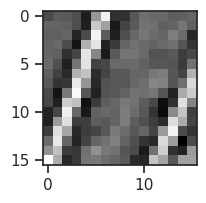

In [8]:
imshow(x[-50].reshape(16, 16), cmap='Greys_r')
plt.show()

In [9]:
df = run_gradient_analysis(x, phi, n_samples=100)

Starting Sweep (n_samples=100, batch_size=90)

firing rates:
[0.1, 0.5, 1, 2, 5, 8, 10, 15, 20, 30, 40, 70, 100]

temperatures:
[0.02, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

  0%|          | 0/13 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

...

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

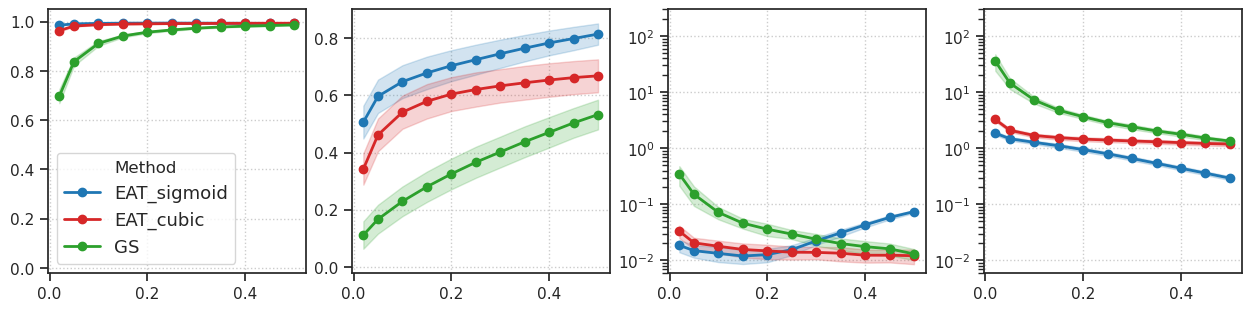

Cos 0.33162951469421387

CosSample 0.028272604569792747

BiasEnergy 1.3133434057235718

NoiseEnergy 132.4735870361328

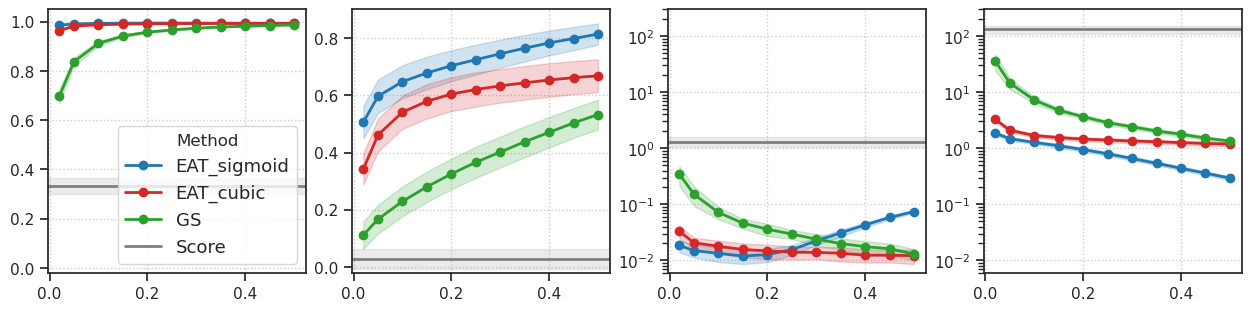

In [70]:
lam = 10
rates_to_plot = [lam]

df_selected = df.loc[df['Rate'].isin(rates_to_plot)]

order = ['EAT_sigmoid', 'EAT_cubic', 'GS', 'Score']
metrics = ['Cos', 'CosSample', 'BiasEnergy', 'NoiseEnergy']
ylim = {
    'Cos': (-0.02, 1.05),
    'CosSample': (-0.02, 0.9),
    'BiasEnergy': (6e-3, 3e2),
    'NoiseEnergy': (6e-3, 3e2),
}
yscale = {
    'Cos': 'linear',
    'CosSample': 'linear',
    'BiasEnergy': 'log',
    'NoiseEnergy': 'log',
}

fig, axes = plot_metrics_vs_temp(
    df_selected,
    metrics=metrics,
    order=order,
    ylim=ylim,
    yscale=yscale,
    sharey=False,
    legend=(0, 0),
    metrics_as_rows=False,
    add_labels=False,
)

# add score based results
df_score = df_selected.loc[df_selected['Method'] == 'Score']

for i, metric in enumerate(metrics):
    val = df_score[f"{metric}Mean"].values.item()
    sd = df_score[f"{metric}Std"].values.item()
    axes[0, i].axhline(val, color=COLORMAPS['Score'], ls='-', lw=2)
    axes[0, i].axhspan(val - sd, val + sd, color=COLORMAPS['Score'], alpha=0.15)
    print(metric, val)
    
# fix legend (add score at the bottom)
# Get existing legend handles and labels
ax_legend = axes[0, 0]
handles, labels = ax_legend.get_legend_handles_labels()

# Add custom handle for Score
score_handle = matplotlib.lines.Line2D(
    [0], [0], color=COLORMAPS['Score'], ls='-', lw=2, label='Score')
handles.append(score_handle)
labels.append('Score')

# Recreate legend with Score added
ax_legend.legend(handles, labels, loc='lower right', framealpha=0.8, title='Method', fontsize=13)


fig.savefig(fig_dir / f'grad_analysis_lam-{lam}.pdf', bbox_inches='tight')

fig

## Test score based bias

In [9]:
lamb = torch.arange(1, 512 + 1).float().to(device)
lamb = lamb.reshape(1, -1)  # (1, 512)
x_single = x[-50]           # (1, 256)

for n_samples in [1000, 10_000, 50_000, 100_000, 500_000, 1_000_000]:
    bias = verify_score_gradient(lamb, phi, x_single, n_samples=n_samples)
    print(f"N={n_samples}\tMean absolute bias: {bias:.6f}")

N=1000  Mean absolute bias: 85447.046875

N=10000 Mean absolute bias: 26518.044922

N=50000 Mean absolute bias: 11950.034180

N=100000        Mean absolute bias: 8319.979492

N=500000        Mean absolute bias: 3689.121826

N=1000000       Mean absolute bias: 2761.184082

In [25]:
log_rates = torch.rand((1, 512)) * 5
rates = log_rates.exp().to(device)

rates.min(), rates.max(), rates.mean()

(tensor(1.0097, device='cuda:0'),
 tensor(147.4126, device='cuda:0'),
 tensor(31.7443, device='cuda:0'))

In [26]:
for n_samples in [1000, 10_000, 50_000, 100_000, 500_000, 1_000_000]:
    bias = verify_score_gradient(rates, phi, x[-50] , n_samples=n_samples)
    print(f"N={n_samples}\tMean absolute bias: {bias:.6f}")

N=1000  Mean absolute bias: 2043.992065

N=10000 Mean absolute bias: 641.988586

N=50000 Mean absolute bias: 275.894348

N=100000        Mean absolute bias: 199.674469

N=500000        Mean absolute bias: 95.989288

N=1000000       Mean absolute bias: 65.850266

In [27]:
rates = torch.ones(1, 512).to(device) * 5.0

for n_samples in [1000, 10_000, 50_000, 100_000, 500_000, 1_000_000]:
    bias = verify_score_gradient(rates, phi, x[-50] , n_samples=n_samples)
    print(f"N={n_samples}\tMean absolute bias: {bias:.6f}")

N=1000  Mean absolute bias: 25.442474

N=10000 Mean absolute bias: 7.432941

N=50000 Mean absolute bias: 3.167946

N=100000        Mean absolute bias: 2.311339

N=500000        Mean absolute bias: 1.034125

N=1000000       Mean absolute bias: 0.712801